In [1]:
!pip install ipython-autotime

In [2]:
%load_ext autotime

time: 333 µs (started: 2021-08-18 18:13:56 -07:00)


## 4.3 Imports<a id='4.3_Imports'></a>

In [3]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import datetime

time: 932 ms (started: 2021-08-18 18:13:56 -07:00)


In [4]:
#return the first 5 and last 5 rows of this dataframe
def p(df_):
    if df_.shape[0] > 6:
        print(df_.shape)
        return pd.concat([df_.head(), df_.tail()])
    else:
        return df_

def rcp(file_, pd_=None, ic_=None):
    if (pd_ == None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_))
    elif (pd_ != None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_)
    elif (pd_ != None) and (ic_ != None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_, index_col = ic_)
    else:
        return pd.read_csv(os.path.join('..', 'processed_data', file_), index_col = ic_)
    
def rcr(file_, pd_=None):
    if pd_ == None:
        return pd.read_csv(os.path.join('..', 'raw_data', file_))
    else:
        return pd.read_csv(os.path.join('..', 'raw_data', file_), parse_dates=pd_)
    
#sort dataframe by column
def s(df_, column_):
    return df_.sort_values(column_)

#reset index and sort dataframe by column
def sr(df_, column_, ascending_=True):
    df_ = df_.sort_values(column_, ascending=ascending_)
    return df_.reset_index(drop=True)

#print length of list
def pl(list_):
    print(len(list_))
    return list_

#print length of dictionary
def pdc(dict_):
    print(len(dict_))
    return dict_

time: 655 µs (started: 2021-08-18 18:13:57 -07:00)


## 4.4 Load Data<a id='4.4_Load_Data'></a>

In [5]:
df_train = rcp('161_train_split.csv', None, 0)
p(df_train)

(7186, 853)


,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff,spread_a
3134,-0.999416,1.099997,-1.006300,-0.869106,0.869106,-1.099997,1.006300,-0.446871,-1.416010,-0.196035,...,0.681655,-1.529913,0.347225,1.073355,1.120699,0.670210,-0.018242,0.800259,-0.480626,11
8383,-0.999416,-1.376256,1.381831,1.147929,-1.147929,1.376256,-1.381831,-1.074563,1.622779,0.541892,...,0.822020,0.882326,-0.004867,-0.341903,-0.861733,-2.815468,-0.223585,-0.786289,-0.970517,-10
7423,-0.999416,-0.614332,0.617629,0.321641,-0.321641,0.614332,-0.617629,2.156205,-0.839025,-0.291209,...,-0.641787,-1.132292,-1.614433,-0.398513,-1.297868,0.016646,-0.037798,-0.714716,1.478941,22
2528,-0.999416,0.147592,-0.242098,-0.605934,0.605934,-0.147592,0.242098,0.125436,-0.031245,-0.757113,...,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266,10
10064,-0.999416,1.385719,-1.388401,-0.777675,0.777675,-1.385719,1.388401,2.137743,-0.781326,-0.260570,...,0.398060,-0.321900,-1.528206,-1.805683,0.520305,-0.774746,-0.624492,1.636988,-0.270672,4
3378,1.000585,1.004757,-0.910774,-0.595496,0.595496,-1.004757,0.910774,0.993128,-0.858258,-0.209483,...,-0.289963,-1.556421,0.280465,1.363611,-1.369957,-0.997370,0.808996,1.480208,0.855443,-5
1965,1.000585,-0.614332,0.426579,0.488491,-0.488491,0.614332,-0.426579,0.402359,0.468809,-0.000505,...,0.461081,-1.344357,-1.010846,0.733693,-2.209787,0.514600,-0.546266,-1.012939,0.499158,14
1161,-0.999416,0.528554,-0.528673,-0.300758,0.300758,-0.528554,0.528673,-0.188410,-0.569765,-0.042986,...,-1.403768,0.511212,-0.457557,-0.624954,-0.980679,-0.325698,-0.282254,0.287315,0.009266,-8
2771,-0.999416,0.433314,-0.528673,-0.729611,0.729611,-0.433314,0.528673,0.771590,-0.165875,-0.721090,...,1.062646,0.378671,-1.362938,0.507252,2.072266,0.234500,-1.103625,0.740614,0.499158,-4
9937,1.000585,-0.900053,0.904205,0.538977,-0.538977,0.900053,-0.904205,-0.059179,-1.185216,-0.131998,...,-0.842308,-1.476897,1.504101,-1.134447,-0.267004,0.514600,-1.005843,-0.237558,1.478941,-8


time: 850 ms (started: 2021-08-18 18:13:57 -07:00)


In [6]:
df_test = rcp('161_test_split.csv', None, 0)
p(df_test)

(3080, 853)


,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff,spread_a
2583,1.000585,-0.328610,0.426579,1.350913,-1.350913,0.328610,-0.426579,0.070052,-0.031245,-0.273612,...,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266,7
9370,-0.999416,1.385719,-1.388401,-1.970642,1.970642,-1.385719,1.388401,0.771590,-0.762094,-0.970663,...,-1.463925,-2.033568,-0.407258,-2.889366,-1.734003,-3.033323,-2.384573,1.170055,1.968833,15
5655,-0.999416,1.385719,-1.770502,-1.539212,1.539212,-1.385719,1.770502,1.362359,-0.127410,-0.408668,...,-1.075642,0.684720,1.197735,-0.722736,0.140296,0.141134,0.169322,1.661311,-1.193195,-1
7258,1.000585,-2.614383,2.623659,1.681878,-1.681878,2.614383,-2.623659,-0.705333,-0.877491,-0.030213,...,1.944940,-0.177999,-0.859949,0.944695,-1.957478,-1.539461,0.079540,-2.623345,0.855443,-5
2386,1.000585,0.052352,-0.051047,-0.051521,0.051521,-0.052352,0.051047,0.014667,0.007220,-0.013957,...,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266,-10
8109,-0.999416,0.528554,-0.624199,-0.788287,0.788287,-0.528554,0.624199,0.014667,0.314946,0.153835,...,0.541290,0.670261,-0.105465,1.299796,1.120699,-0.263454,-0.164915,-0.523853,0.009266,2
9743,1.000585,-0.328610,0.331054,0.243728,-0.243728,0.328610,-0.331054,-1.499179,0.853465,0.406982,...,0.260560,1.465504,-1.564134,0.563862,1.398239,-0.885896,1.174702,-1.358878,0.009266,24
4546,1.000585,1.004757,-0.910774,-0.694836,0.694836,-1.004757,0.910774,-0.188410,0.103385,0.029099,...,0.681655,-0.310540,0.799916,-0.511734,0.407023,-0.450186,-0.380036,0.943406,0.499158,6
4962,-0.999416,0.623795,-0.624199,-0.319306,0.319306,-0.623795,0.624199,0.476205,-1.377545,-0.130825,...,0.922281,2.101699,-1.463536,2.375392,0.327726,0.203378,1.252928,-2.181974,2.458724,10
5706,-0.999416,0.242833,-0.146573,-0.192442,0.192442,-0.242833,0.146573,-0.114564,0.353411,0.091763,...,-0.461318,1.757094,-1.061144,0.054369,-3.438895,-1.134873,1.712504,-1.144157,0.989049,5


time: 383 ms (started: 2021-08-18 18:13:58 -07:00)


In [7]:
X_train = df_train.drop(columns = 'spread_a')
p(X_train)

(7186, 852)


,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,dreb_cma_sm_cmax12_diff,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff
3134,-0.999416,1.099997,-1.006300,-0.869106,0.869106,-1.099997,1.006300,-0.446871,-1.416010,-0.196035,...,0.130110,0.681655,-1.529913,0.347225,1.073355,1.120699,0.670210,-0.018242,0.800259,-0.480626
8383,-0.999416,-1.376256,1.381831,1.147929,-1.147929,1.376256,-1.381831,-1.074563,1.622779,0.541892,...,-0.585219,0.822020,0.882326,-0.004867,-0.341903,-0.861733,-2.815468,-0.223585,-0.786289,-0.970517
7423,-0.999416,-0.614332,0.617629,0.321641,-0.321641,0.614332,-0.617629,2.156205,-0.839025,-0.291209,...,-0.134827,-0.641787,-1.132292,-1.614433,-0.398513,-1.297868,0.016646,-0.037798,-0.714716,1.478941
2528,-0.999416,0.147592,-0.242098,-0.605934,0.605934,-0.147592,0.242098,0.125436,-0.031245,-0.757113,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
10064,-0.999416,1.385719,-1.388401,-0.777675,0.777675,-1.385719,1.388401,2.137743,-0.781326,-0.260570,...,0.043060,0.398060,-0.321900,-1.528206,-1.805683,0.520305,-0.774746,-0.624492,1.636988,-0.270672
3378,1.000585,1.004757,-0.910774,-0.595496,0.595496,-1.004757,0.910774,0.993128,-0.858258,-0.209483,...,-1.305366,-0.289963,-1.556421,0.280465,1.363611,-1.369957,-0.997370,0.808996,1.480208,0.855443
1965,1.000585,-0.614332,0.426579,0.488491,-0.488491,0.614332,-0.426579,0.402359,0.468809,-0.000505,...,0.289072,0.461081,-1.344357,-1.010846,0.733693,-2.209787,0.514600,-0.546266,-1.012939,0.499158
1161,-0.999416,0.528554,-0.528673,-0.300758,0.300758,-0.528554,0.528673,-0.188410,-0.569765,-0.042986,...,-0.982624,-1.403768,0.511212,-0.457557,-0.624954,-0.980679,-0.325698,-0.282254,0.287315,0.009266
2771,-0.999416,0.433314,-0.528673,-0.729611,0.729611,-0.433314,0.528673,0.771590,-0.165875,-0.721090,...,0.474528,1.062646,0.378671,-1.362938,0.507252,2.072266,0.234500,-1.103625,0.740614,0.499158
9937,1.000585,-0.900053,0.904205,0.538977,-0.538977,0.900053,-0.904205,-0.059179,-1.185216,-0.131998,...,-0.744181,-0.842308,-1.476897,1.504101,-1.134447,-0.267004,0.514600,-1.005843,-0.237558,1.478941


time: 22.4 ms (started: 2021-08-18 18:13:58 -07:00)


In [8]:
y_train = df_train.spread_a
p(y_train)

(7186,)


3134     11
8383    -10
7423     22
2528     10
10064     4
3378     -5
1965     14
1161     -8
2771     -4
9937     -8
Name: spread_a, dtype: int64

time: 2.39 ms (started: 2021-08-18 18:13:58 -07:00)


In [9]:
X_test = df_test.drop(columns = 'spread_a')
p(X_test)

(3080, 852)


,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,dreb_cma_sm_cmax12_diff,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff
2583,1.000585,-0.328610,0.426579,1.350913,-1.350913,0.328610,-0.426579,0.070052,-0.031245,-0.273612,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
9370,-0.999416,1.385719,-1.388401,-1.970642,1.970642,-1.385719,1.388401,0.771590,-0.762094,-0.970663,...,-1.538992,-1.463925,-2.033568,-0.407258,-2.889366,-1.734003,-3.033323,-2.384573,1.170055,1.968833
5655,-0.999416,1.385719,-1.770502,-1.539212,1.539212,-1.385719,1.770502,1.362359,-0.127410,-0.408668,...,-1.156038,-1.075642,0.684720,1.197735,-0.722736,0.140296,0.141134,0.169322,1.661311,-1.193195
7258,1.000585,-2.614383,2.623659,1.681878,-1.681878,2.614383,-2.623659,-0.705333,-0.877491,-0.030213,...,2.117137,1.944940,-0.177999,-0.859949,0.944695,-1.957478,-1.539461,0.079540,-2.623345,0.855443
2386,1.000585,0.052352,-0.051047,-0.051521,0.051521,-0.052352,0.051047,0.014667,0.007220,-0.013957,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
8109,-0.999416,0.528554,-0.624199,-0.788287,0.788287,-0.528554,0.624199,0.014667,0.314946,0.153835,...,0.606997,0.541290,0.670261,-0.105465,1.299796,1.120699,-0.263454,-0.164915,-0.523853,0.009266
9743,1.000585,-0.328610,0.331054,0.243728,-0.243728,0.328610,-0.331054,-1.499179,0.853465,0.406982,...,0.209591,0.260560,1.465504,-1.564134,0.563862,1.398239,-0.885896,1.174702,-1.358878,0.009266
4546,1.000585,1.004757,-0.910774,-0.694836,0.694836,-1.004757,0.910774,-0.188410,0.103385,0.029099,...,0.262579,0.681655,-0.310540,0.799916,-0.511734,0.407023,-0.450186,-0.380036,0.943406,0.499158
4962,-0.999416,0.623795,-0.624199,-0.319306,0.319306,-0.623795,0.624199,0.476205,-1.377545,-0.130825,...,2.355580,0.922281,2.101699,-1.463536,2.375392,0.327726,0.203378,1.252928,-2.181974,2.458724
5706,-0.999416,0.242833,-0.146573,-0.192442,0.192442,-0.242833,0.146573,-0.114564,0.353411,0.091763,...,-0.267295,-0.461318,1.757094,-1.061144,0.054369,-3.438895,-1.134873,1.712504,-1.144157,0.989049


time: 17.4 ms (started: 2021-08-18 18:13:58 -07:00)


In [10]:
y_test = df_test.spread_a
p(y_test)

(3080,)


2583     7
9370    15
5655    -1
7258    -5
2386   -10
8109     2
9743    24
4546     6
4962    10
5706     5
Name: spread_a, dtype: int64

time: 2.25 ms (started: 2021-08-18 18:13:58 -07:00)


## 4.8 Initial Models<a id='4.8_Initial_Models'></a>

### 4.8.1 Imputing missing feature (predictor) values<a id='4.8.1_Imputing_missing_feature_(predictor)_values'></a>

Recall when performing EDA, you imputed (filled in) some missing values in pandas. You did this judiciously for exploratory/visualization purposes. You left many missing values in the data. You can impute missing values using scikit-learn, but note that you should learn values to impute from a train split and apply that to the test split to then assess how well your imputation worked.

#### 4.8.1.1 Impute missing values with median<a id='4.8.1.1_Impute_missing_values_with_median'></a>

There's missing values. Recall from your data exploration that many distributions were skewed. Your first thought might be to impute missing values using the median.

In [11]:
X_tr_scaled = X_train
X_tr_scaled

,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,dreb_cma_sm_cmax12_diff,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff
3134,-0.999416,1.099997,-1.006300,-0.869106,0.869106,-1.099997,1.006300,-0.446871,-1.416010,-0.196035,...,0.130110,0.681655,-1.529913,0.347225,1.073355,1.120699,0.670210,-0.018242,0.800259,-0.480626
8383,-0.999416,-1.376256,1.381831,1.147929,-1.147929,1.376256,-1.381831,-1.074563,1.622779,0.541892,...,-0.585219,0.822020,0.882326,-0.004867,-0.341903,-0.861733,-2.815468,-0.223585,-0.786289,-0.970517
7423,-0.999416,-0.614332,0.617629,0.321641,-0.321641,0.614332,-0.617629,2.156205,-0.839025,-0.291209,...,-0.134827,-0.641787,-1.132292,-1.614433,-0.398513,-1.297868,0.016646,-0.037798,-0.714716,1.478941
2528,-0.999416,0.147592,-0.242098,-0.605934,0.605934,-0.147592,0.242098,0.125436,-0.031245,-0.757113,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
10064,-0.999416,1.385719,-1.388401,-0.777675,0.777675,-1.385719,1.388401,2.137743,-0.781326,-0.260570,...,0.043060,0.398060,-0.321900,-1.528206,-1.805683,0.520305,-0.774746,-0.624492,1.636988,-0.270672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3378,1.000585,1.004757,-0.910774,-0.595496,0.595496,-1.004757,0.910774,0.993128,-0.858258,-0.209483,...,-1.305366,-0.289963,-1.556421,0.280465,1.363611,-1.369957,-0.997370,0.808996,1.480208,0.855443
1965,1.000585,-0.614332,0.426579,0.488491,-0.488491,0.614332,-0.426579,0.402359,0.468809,-0.000505,...,0.289072,0.461081,-1.344357,-1.010846,0.733693,-2.209787,0.514600,-0.546266,-1.012939,0.499158
1161,-0.999416,0.528554,-0.528673,-0.300758,0.300758,-0.528554,0.528673,-0.188410,-0.569765,-0.042986,...,-0.982624,-1.403768,0.511212,-0.457557,-0.624954,-0.980679,-0.325698,-0.282254,0.287315,0.009266
2771,-0.999416,0.433314,-0.528673,-0.729611,0.729611,-0.433314,0.528673,0.771590,-0.165875,-0.721090,...,0.474528,1.062646,0.378671,-1.362938,0.507252,2.072266,0.234500,-1.103625,0.740614,0.499158


time: 12.8 ms (started: 2021-08-18 18:13:58 -07:00)


In [12]:
X_te_scaled = X_test
X_te_scaled

,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,dreb_cma_sm_cmax12_diff,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff
2583,1.000585,-0.328610,0.426579,1.350913,-1.350913,0.328610,-0.426579,0.070052,-0.031245,-0.273612,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
9370,-0.999416,1.385719,-1.388401,-1.970642,1.970642,-1.385719,1.388401,0.771590,-0.762094,-0.970663,...,-1.538992,-1.463925,-2.033568,-0.407258,-2.889366,-1.734003,-3.033323,-2.384573,1.170055,1.968833
5655,-0.999416,1.385719,-1.770502,-1.539212,1.539212,-1.385719,1.770502,1.362359,-0.127410,-0.408668,...,-1.156038,-1.075642,0.684720,1.197735,-0.722736,0.140296,0.141134,0.169322,1.661311,-1.193195
7258,1.000585,-2.614383,2.623659,1.681878,-1.681878,2.614383,-2.623659,-0.705333,-0.877491,-0.030213,...,2.117137,1.944940,-0.177999,-0.859949,0.944695,-1.957478,-1.539461,0.079540,-2.623345,0.855443
2386,1.000585,0.052352,-0.051047,-0.051521,0.051521,-0.052352,0.051047,0.014667,0.007220,-0.013957,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8109,-0.999416,0.528554,-0.624199,-0.788287,0.788287,-0.528554,0.624199,0.014667,0.314946,0.153835,...,0.606997,0.541290,0.670261,-0.105465,1.299796,1.120699,-0.263454,-0.164915,-0.523853,0.009266
9743,1.000585,-0.328610,0.331054,0.243728,-0.243728,0.328610,-0.331054,-1.499179,0.853465,0.406982,...,0.209591,0.260560,1.465504,-1.564134,0.563862,1.398239,-0.885896,1.174702,-1.358878,0.009266
4546,1.000585,1.004757,-0.910774,-0.694836,0.694836,-1.004757,0.910774,-0.188410,0.103385,0.029099,...,0.262579,0.681655,-0.310540,0.799916,-0.511734,0.407023,-0.450186,-0.380036,0.943406,0.499158
4962,-0.999416,0.623795,-0.624199,-0.319306,0.319306,-0.623795,0.624199,0.476205,-1.377545,-0.130825,...,2.355580,0.922281,2.101699,-1.463536,2.375392,0.327726,0.203378,1.252928,-2.181974,2.458724


time: 13.1 ms (started: 2021-08-18 18:13:58 -07:00)


### 4.8.2 Pipelines<a id='4.8.2_Pipelines'></a>

One of the most important and useful components of `sklearn` is the [pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html). In place of `panda`'s `fillna` DataFrame method, there is `sklearn`'s `SimpleImputer`. Remember the first linear model above performed the steps:

1. replace missing values with the median for each feature
2. scale the data to zero mean and unit variance
3. train a linear regression model

and all these steps were trained on the train split and then applied to the test split for assessment.

The pipeline below defines exactly those same steps. Crucially, the resultant `Pipeline` object has a `fit()` method and a `predict()` method, just like the `LinearRegression()` object itself. Just as you might create a linear regression model and train it with `.fit()` and predict with `.predict()`, you can wrap the entire process of imputing and feature scaling and regression in a single object you can train with `.fit()` and predict with `.predict()`. And that's basically a pipeline: a model on steroids.

#### 4.8.2.2 Fit the pipeline<a id='4.8.2.2_Fit_the_pipeline'></a>

Here, a single call to the pipeline's `fit()` method combines the steps of learning the imputation (determining what values to use to fill the missing ones), the scaling (determining the mean to subtract and the variance to divide by), and then training the model. It does this all in the one call with the training data as arguments.

#### 4.8.2.3 Make predictions on the train and test sets<a id='4.8.2.3_Make_predictions_on_the_train_and_test_sets'></a>

#### 4.8.2.4 Assess performance<a id='4.8.2.4_Assess_performance'></a>

And compare with your earlier (non-pipeline) result:

## 4.9 Refining The Linear Model<a id='4.9_Refining_The_Linear_Model'></a>

You suspected the model was overfitting. This is no real surprise given the number of features you blindly used. It's likely a judicious subset of features would generalize better. `sklearn` has a number of feature selection functions available. The one you'll use here is `SelectKBest` which, as you might guess, selects the k best features. You can read about SelectKBest 
[here](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html#sklearn.feature_selection.SelectKBest). `f_regression` is just the [score function](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_regression.html#sklearn.feature_selection.f_regression) you're using because you're performing regression. It's important to choose an appropriate one for your machine learning task.

### 4.9.1 Define the pipeline<a id='4.9.1_Define_the_pipeline'></a>

Redefine your pipeline to include this feature selection step:

### 4.9.2 Fit the pipeline<a id='4.9.2_Fit_the_pipeline'></a>

### 4.9.3 Assess performance on the train and test set<a id='4.9.3_Assess_performance_on_the_train_and_test_set'></a>

### 4.9.4 Define a new pipeline to select a different number of features<a id='4.9.4_Define_a_new_pipeline_to_select_a_different_number_of_features'></a>

### 4.9.5 Fit the pipeline<a id='4.9.5_Fit_the_pipeline'></a>

### 4.9.6 Assess performance on train and test data<a id='4.9.6_Assess_performance_on_train_and_test_data'></a>

### 4.9.7 Assessing performance using cross-validation<a id='4.9.7_Assessing_performance_using_cross-validation'></a>

### 4.9.8 Hyperparameter search using GridSearchCV<a id='4.9.8_Hyperparameter_search_using_GridSearchCV'></a>

Pulling the above together, we have:
* a pipeline that
    * imputes missing values
    * scales the data
    * selects the k best features
    * trains a linear regression model
* a technique (cross-validation) for estimating model performance

Now you want to use cross-validation for multiple values of k and use cross-validation to pick the value of k that gives the best performance. `make_pipeline` automatically names each step as the lowercase name of the step and the parameters of the step are then accessed by appending a double underscore followed by the parameter name. You know the name of the step will be 'selectkbest' and you know the parameter is 'k'.

You can also list the names of all the parameters in a pipeline like this:

The above can be particularly useful as your pipelines becomes more complex (you can even nest pipelines within pipelines).

Now you have a range of `k` to investigate. Is 1 feature best? 2? 3? 4? All of them? You could write a for loop and iterate over each possible value, doing all the housekeeping oyurselves to track the best value of k. But this is  a common task so there's a built in function in `sklearn`. This is [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
This takes the pipeline object, in fact it takes anything with a `.fit()` and `.predict()` method. In simple cases with no feature selection or imputation or feature scaling etc. you may see the classifier or regressor object itself directly passed into `GridSearchCV`. The other key input is the parameters and values to search over. Optional parameters include the cross-validation strategy and number of CPUs to use.

The above suggests a good value for k is 8. There was an initial rapid increase with k, followed by a slow decline. Also noticeable is the variance of the results greatly increase above k=8. As you increasingly overfit, expect greater swings in performance as different points move in and out of the train/test folds.

Which features were most useful? Step into your best model, shown below. Starting with the fitted grid search object, you get the best estimator, then the named step 'selectkbest', for which you can its `get_support()` method for a logical mask of the features selected.

Similarly, instead of using the 'selectkbest' named step, you can access the named step for the linear regression model and, from that, grab the model coefficients via its `coef_` attribute:

These results suggest that vertical drop is your biggest positive feature. This makes intuitive sense and is consistent with what you saw during the EDA work. Also, you see the area covered by snow making equipment is a strong positive as well. People like guaranteed skiing! The skiable terrain area is negatively associated with ticket price! This seems odd. People will pay less for larger resorts? There could be all manner of reasons for this. It could be  an effect whereby larger resorts can host more visitors at any one time and so can charge less per ticket. As has been mentioned previously, the data are missing information about visitor numbers. Bear in mind,  the coefficient for skiable terrain is negative _for this model_. For example, if you kept the total number of chairs and fastQuads constant, but increased the skiable terrain extent, you might imagine the resort is worse off because the chairlift capacity is stretched thinner.

<font color='red'>"As has been mentioned previously, the data are missing information about visitor numbers"!!!<font>

## 4.10 Random Forest Model<a id='4.10_Random_Forest_Model'></a>

A model that can work very well in a lot of cases is the random forest. For regression, this is provided by `sklearn`'s `RandomForestRegressor` class.

Time to stop the bad practice of repeatedly checking performance on the test split. Instead, go straight from defining the pipeline to assessing performance using cross-validation. `cross_validate` will perform the fitting as part of the process. This uses the default settings for the random forest so you'll then proceed to investigate some different hyperparameters.

### 4.10.1 Define the pipeline<a id='4.10.1_Define_the_pipeline'></a>

In [13]:
RF_pipe = make_pipeline(
    RandomForestRegressor(random_state=47)
)

time: 367 µs (started: 2021-08-18 18:13:58 -07:00)


In [14]:
type(RF_pipe)

sklearn.pipeline.Pipeline

time: 887 µs (started: 2021-08-18 18:13:58 -07:00)


In [15]:
hasattr(RF_pipe, 'fit'), hasattr(RF_pipe, 'predict')

(True, True)

time: 1.03 ms (started: 2021-08-18 18:13:58 -07:00)


In [16]:
#Code task 18#
#Call `pipe`'s `get_params()` method to get a dict of available parameters and print their names
#using dict's `keys()` method
RF_pipe.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'randomforestregressor', 'randomforestregressor__bootstrap', 'randomforestregressor__ccp_alpha', 'randomforestregressor__criterion', 'randomforestregressor__max_depth', 'randomforestregressor__max_features', 'randomforestregressor__max_leaf_nodes', 'randomforestregressor__max_samples', 'randomforestregressor__min_impurity_decrease', 'randomforestregressor__min_impurity_split', 'randomforestregressor__min_samples_leaf', 'randomforestregressor__min_samples_split', 'randomforestregressor__min_weight_fraction_leaf', 'randomforestregressor__n_estimators', 'randomforestregressor__n_jobs', 'randomforestregressor__oob_score', 'randomforestregressor__random_state', 'randomforestregressor__verbose', 'randomforestregressor__warm_start'])

time: 906 µs (started: 2021-08-18 18:13:58 -07:00)


### 4.10.2 Fit and assess performance using cross-validation<a id='4.10.2_Fit_and_assess_performance_using_cross-validation'></a>

In [17]:
rf_default_cv_results = cross_validate(RF_pipe, X_train, y_train, cv=5)

time: 17min 34s (started: 2021-08-18 18:13:58 -07:00)


In [18]:
rf_cv_scores = rf_default_cv_results['test_score']
rf_cv_scores

array([0.17178679, 0.18483279, 0.17073453, 0.18220283, 0.16305472])

time: 1.02 ms (started: 2021-08-18 18:31:33 -07:00)


In [19]:
np.mean(rf_cv_scores), np.std(rf_cv_scores)

(0.1745223295411953, 0.007982885519787146)

time: 1 ms (started: 2021-08-18 18:31:33 -07:00)


### 4.10.3 Hyperparameter search using GridSearchCV<a id='4.10.3_Hyperparameter_search_using_GridSearchCV'></a>

Random forest has a number of hyperparameters that can be explored, however here you'll limit yourselves to exploring some different values for the number of trees. You'll try it with and without feature scaling, and try both the mean and median as strategies for imputing missing values.

In [20]:
'''n_est = [int(n) for n in np.logspace(start=1, stop=3, num=20)]
n_est
'''

'n_est = [int(n) for n in np.logspace(start=1, stop=3, num=20)]\nn_est\n'

time: 710 µs (started: 2021-08-18 18:31:33 -07:00)


In [21]:
'''grid_params = {
        #SimpleImputer(strategy='median'),
    #StandardScaler(),
        'randomforestregressor__n_estimators': [100],
        'randomforestregressor__max_depth': [5, 10, 20, 1000],
        'randomforestregressor__min_samples_split': [50, 100, 1000],
        'randomforestregressor__max_features': [5, 10, 20, 40, 100, 300]
}
grid_params'''

"grid_params = {\n        #SimpleImputer(strategy='median'),\n    #StandardScaler(),\n        'randomforestregressor__n_estimators': [100],\n        'randomforestregressor__max_depth': [5, 10, 20, 1000],\n        'randomforestregressor__min_samples_split': [50, 100, 1000],\n        'randomforestregressor__max_features': [5, 10, 20, 40, 100, 300]\n}\ngrid_params"

time: 601 µs (started: 2021-08-18 18:31:33 -07:00)


In [22]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV


# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]


# Number of features to consider at every split
max_features = ['auto', 'sqrt']


# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)

# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]

# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]

# Method of selecting samples for training each tree
bootstrap = [True, False]


# Create the random grid
random_grid = {'n_estimators': [50],
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
print(random_grid)




{'n_estimators': [50], 'max_features': ['auto', 'sqrt'], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}
time: 677 µs (started: 2021-08-18 18:31:33 -07:00)


In [23]:
'''#Code task 24#
#Call `GridSearchCV` with the random forest pipeline, passing in the above `grid_params`
#dict for parameters to evaluate, 5-fold cross-validation, and all available CPU cores (if desired)
rf_grid_cv = RandomizedSearchCV(RF_pipe, param_grid=random_grid, cv=5, n_jobs=-1)'''

'#Code task 24#\n#Call `GridSearchCV` with the random forest pipeline, passing in the above `grid_params`\n#dict for parameters to evaluate, 5-fold cross-validation, and all available CPU cores (if desired)\nrf_grid_cv = RandomizedSearchCV(RF_pipe, param_grid=random_grid, cv=5, n_jobs=-1)'

time: 653 µs (started: 2021-08-18 18:31:33 -07:00)


In [24]:
rf = RandomForestRegressor()

# search across 100 different combinations, and use all available cores
rf_random = RandomizedSearchCV(estimator = rf,
                               param_distributions = random_grid,
                               n_iter = 100,
                               cv = 3,
                               verbose=2,
                               random_state=42,
                               n_jobs = -1)

# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  4.5min
/opt/anaconda3/lib/python3.8/site-packages/joblib/externals/loky/process_executor.py:688: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed: 18.6min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 45.7min finished


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110,
                                                      None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50]},
                   random_state=42, verbose=2)

time: 47min 12s (started: 2021-08-18 18:31:33 -07:00)


In [25]:
#Code task 26#
#Print the best params (`best_params_` attribute) from the grid search
rf_random.best_params_

{'n_estimators': 50,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_features': 'auto',
 'max_depth': 10,
 'bootstrap': True}

time: 1.01 ms (started: 2021-08-18 19:18:46 -07:00)


In [26]:
rf_best_cv_results = cross_validate(rf_random.best_estimator_, X_train, y_train, cv=5)
rf_best_scores = rf_best_cv_results['test_score']
rf_best_scores

array([0.17021952, 0.1907618 , 0.16992721, 0.1854238 , 0.16966509])

time: 6min 1s (started: 2021-08-18 19:18:46 -07:00)


In [27]:
np.mean(rf_best_scores), np.std(rf_best_scores)

(0.1771994834275062, 0.009054820062006981)

time: 1.01 ms (started: 2021-08-18 19:24:47 -07:00)


In [29]:
rf_random.best_estimator_.feature_importances_

array([7.71187641e-02, 2.65367112e-03, 2.62809286e-03, 4.88331455e-04,
       7.83030830e-03, 3.61187921e-03, 2.56627212e-03, 1.84385080e-03,
       2.20181679e-03, 1.87760455e-03, 8.77755471e-03, 2.96486162e-04,
       1.66521641e-03, 8.50741865e-04, 1.22274612e-03, 8.49875711e-04,
       6.21851399e-04, 5.36073400e-04, 1.45404712e-04, 6.97546757e-04,
       1.69696645e-03, 6.64638212e-04, 1.18748686e-03, 8.68315932e-04,
       2.97057226e-04, 8.92258930e-04, 9.26462042e-04, 1.18530769e-03,
       9.32718314e-04, 8.99100102e-04, 4.21208760e-04, 3.93652386e-04,
       2.12358005e-04, 8.75203491e-04, 8.81436343e-04, 1.23288616e-03,
       7.28539208e-04, 5.77084699e-04, 4.59569026e-04, 4.90740742e-04,
       4.56543599e-04, 2.47197299e-04, 1.31095751e-03, 1.04272540e-03,
       6.47916529e-04, 1.32760864e-03, 3.89263793e-04, 4.05261613e-04,
       7.28485783e-04, 5.72537132e-04, 1.01468010e-03, 1.31846798e-03,
       3.99156774e-04, 6.90698472e-04, 3.39243539e-04, 3.43013266e-04,
      

time: 25 ms (started: 2021-08-18 22:06:50 -07:00)


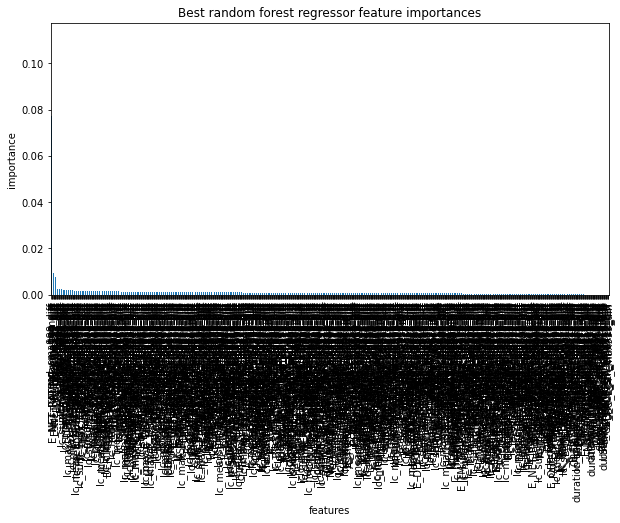

time: 8.16 s (started: 2021-08-18 22:07:17 -07:00)


In [31]:
#Code task 27#
#Plot a barplot of the random forest's feature importances,
#assigning the `feature_importances_` attribute of 
#`rf_grid_cv.best_estimator_.named_steps.randomforestregressor` to the name `imps` to then
#create a pandas Series object of the feature importances, with the index given by the
#training data column names, sorting the values in descending order
plt.subplots(figsize=(10, 5))
imps = rf_random.best_estimator_.feature_importances_
rf_feat_imps = pd.Series(imps, index=X_train.columns).sort_values(ascending=False)
rf_feat_imps.plot(kind='bar')
plt.xlabel('features')
plt.ylabel('importance')
plt.title('Best random forest regressor feature importances');

In [32]:
rf_feat_imps

spread_cma999_diff          0.111939
away_home_a                 0.077119
NET_RATING_cma999_diff      0.045690
E_NET_RATING_cma999_diff    0.038463
PIE_cma999_diff             0.009316
                              ...   
USG_PCT_cma999_diff         0.000000
USG_PCT_sm_cmax12_diff      0.000000
E_PACE_sm_cmax12_diff       0.000000
PACE_sm_cmax12_diff         0.000000
USG_PCT_cmax999_diff        0.000000
Length: 852, dtype: float64

time: 5.8 ms (started: 2021-08-18 22:07:31 -07:00)


In [33]:
rf_feat_imps[0:30]

spread_cma999_diff                0.111939
away_home_a                       0.077119
NET_RATING_cma999_diff            0.045690
E_NET_RATING_cma999_diff          0.038463
PIE_cma999_diff                   0.009316
E_NET_RATING_cma12_diff           0.009227
strength_of_schedule_diff         0.008778
opp_win_pct_diff                  0.007830
spread_cma12_diff                 0.005366
opp_losses_diff                   0.003612
PIE_cma12_diff                    0.002656
losses_diff                       0.002654
wins_diff                         0.002628
opp_wins_diff                     0.002566
EFG_PCT_cma999_diff               0.002352
tov_cma999_diff                   0.002310
lc_sum_AST_TOV_cmax5_diff         0.002288
lc_max_MIN_cma5_diff              0.002262
opp_opps_wins_diff                0.002202
AST_TOV_cmax5_diff                0.002193
NET_RATING_cma5_diff              0.002091
lc_max_TS_PCT_cmax999_diff        0.002059
E_PACE_cma5_diff                  0.002043
TS_PCT_cma5

time: 5.64 ms (started: 2021-08-18 22:07:31 -07:00)


In [36]:
rf_feat_imps[-30:-1]

min_cma12_diff                     0.000036
away_home_sm_cma12_diff            0.000031
duration_minutes_cmax999_diff      0.000028
away_home_sm_cmax12_diff           0.000004
duration_minutes_sm_cmax12_diff    0.000000
min_sm_cmax12_diff                 0.000000
away_home__cmax5_diff_y            0.000000
away_home__cmax5_diff_x            0.000000
USG_PCT_cmax5_diff                 0.000000
USG_PCT_cmax12_diff                0.000000
min_sm_cma12_diff                  0.000000
away_home__cmax999_diff_x          0.000000
USG_PCT_cma5_diff                  0.000000
PACE_PER40_sm_cma12_diff           0.000000
PACE_sm_cma12_diff                 0.000000
E_PACE_sm_cma12_diff               0.000000
USG_PCT_sm_cma12_diff              0.000000
away_home__cmax12_diff_x           0.000000
USG_PCT_cma12_diff                 0.000000
NET_RATING_sm_cma12_diff           0.000000
away_home__cmax999_diff_y          0.000000
PACE_PER40_sm_cmax12_diff          0.000000
USG_PCT_cma_sm_cmax12_diff      

time: 4.88 ms (started: 2021-08-18 22:08:32 -07:00)


In [ ]:
#feature importance affected by collinearity


#https://www.quora.com/Does-the-random-forests-technique-suffer-if-there-is-a-multi-colinerarity-present-in-the-features-data-when-trying-to-predict-the-classification-of-the-next-datapoint-If-not-why



In [ ]:
# can reduce runtime by dropping the bottom 5% of feature importances

#https://towardsdatascience.com/improving-random-forest-in-python-part-1-893916666cd




In [ ]:
#play with max depth

#specify maximum number of features to include in each node split


#https://www.keboola.com/blog/random-forest-regression

In [ ]:
#Randomed Search Cross Validation

#https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74
 

#random_grid = {'n_estimators': n_estimators,
#               'max_features': max_features,
#               'max_depth': max_depth,
#               'min_samples_split': min_samples_split,
#               'min_samples_leaf': min_samples_leaf,
#               'bootstrap': bootstrap}



In [ ]:
#Extra features can decrease performance because they may “confuse” the model by giving it irrelevant
#data that prevents it from learning the actual relationships. 

#https://towardsdatascience.com/improving-random-forest-in-python-part-1-893916666cd


Encouragingly, the dominant top four features are in common with your linear model:
* w_pct_cma_diff
* away_home_a
* spread_cma_diff
* E_NET_RATING_cma_diff


## 4.11 Final Model Selection<a id='4.11_Final_Model_Selection'></a>

Time to select your final model to use for further business modeling! It would be good to revisit the above model selection; there is undoubtedly more that could be done to explore possible hyperparameters.
It would also be worthwhile to investigate removing the least useful features. Gathering or calculating, and storing, features adds business cost and dependencies, so if features genuinely are not needed they should be removed.
Building a simpler model with fewer features can also have the advantage of being easier to sell (and/or explain) to stakeholders.
Certainly there seem to be four strong features here and so a model using only those would probably work well.
However, you want to explore some different scenarios where other features vary so keep the fuller 
model for now. 
The business is waiting for this model and you have something that you have confidence in to be much better than guessing with the average price.

Or, rather, you have two "somethings". You built a best linear model and a best random forest model. You need to finally choose between them. You can calculate the mean absolute error using cross-validation. Although `cross-validate` defaults to the $R^2$ [metric for scoring](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring) regression, you can specify the mean absolute error as an alternative via
the `scoring` parameter.

### 4.11.1 Linear regression model performance<a id='4.11.1_Linear_regression_model_performance'></a>

### 4.11.2 Random forest regression model performance<a id='4.11.2_Random_forest_regression_model_performance'></a>

In [ ]:
rf_neg_mae = cross_validate(rf_grid_cv.best_estimator_, X_train, y_train, 
                            scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

In [ ]:
rf_mae_mean = np.mean(-1 * rf_neg_mae['test_score'])
rf_mae_std = np.std(-1 * rf_neg_mae['test_score'])
rf_mae_mean, rf_mae_std

In [ ]:
mean_absolute_error(y_test, rf_grid_cv.best_estimator_.predict(X_test))

### 4.11.3 Conclusion<a id='4.11.3_Conclusion'></a>

The random forest model has a lower cross-validation mean absolute error by almost \\$1. It also exhibits less variability. Verifying performance on the test set produces performance consistent with the cross-validation results.

## 4.12 Data quantity assessment<a id='4.12_Data_quantity_assessment'></a>

Finally, you need to advise the business whether it needs to undertake further data collection. Would more data be useful? We're often led to believe more data is always good, but gathering data invariably has a cost associated with it. Assess this trade off by seeing how performance varies with differing data set sizes. The `learning_curve` function does this conveniently.

In [ ]:
fractions = [.2, .25, .3, .35, .4, .45, .5, .6, .75, .8, 1.0]
train_size, train_scores, test_scores = learning_curve(pipe, X_train, y_train, train_sizes=fractions)
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

In [ ]:
plt.subplots(figsize=(10, 5))
plt.errorbar(train_size, test_scores_mean, yerr=test_scores_std)
plt.xlabel('Training set size')
plt.ylabel('CV scores')
plt.title('Cross-validation score as training set size increases');

This shows that you seem to have plenty of data. There's an initial rapid improvement in model scores as one would expect, but it's essentially levelled off by around a sample size of 40-50.

## 4.13 Save best model object from pipeline<a id='4.13_Save_best_model_object_from_pipeline'></a>

In [ ]:
#Code task 28#
#This may not be "production grade ML deployment" practice, but adding some basic
#information to your saved models can save your bacon in development.
#Just what version model have you just loaded to reuse? What version of `sklearn`
#created it? When did you make it?
#Assign the pandas version number (`pd.__version__`) to the `pandas_version` attribute,
#the numpy version (`np.__version__`) to the `numpy_version` attribute,
#the sklearn version (`sklearn_version`) to the `sklearn_version` attribute,
#and the current datetime (`datetime.datetime.now()`) to the `build_datetime` attribute
#Let's call this model version '1.0'
best_model = rf_grid_cv.best_estimator_
best_model.version = '1.0'
best_model.pandas_version = pd.__version__
best_model.numpy_version = np.__version__
best_model.sklearn_version = sklearn_version
best_model.X_columns = [col for col in X_train.columns]
best_model.build_datetime = datetime.datetime.now()
    
modelpath = os.path.join('..', 'models')
if not os.path.exists(modelpath):
    os.mkdir(modelpath)
nbamodel_path = os.path.join(modelpath, 'nba_spread_a_model_161_max_features.pkl')
if not os.path.exists(nbamodel_path):
    with open(nbamodel_path, 'wb') as f:
        pickle.dump(best_model, f)

## 4.14 Summary<a id='4.14_Summary'></a>

**Q: 1** Write a summary of the work in this notebook. Capture the fact that you gained a baseline idea of performance by simply taking the average price and how well that did. Then highlight that you built a linear model and the features that found. Comment on the estimate of its performance from cross-validation and whether its performance on the test split was consistent with this estimate. Also highlight that a random forest regressor was tried, what preprocessing steps were found to be best, and again what its estimated performance via cross-validation was and whether its performance on the test set was consistent with that. State which model you have decided to use going forwards and why. This summary should provide a quick overview for someone wanting to know quickly why the given model was chosen for the next part of the business problem to help guide important business decisions.

Capture the fact that you gained a baseline idea of performance by simply taking the average price and how well that did.
-Average price yielded an R^2, explained variance, of 0 and a mean absolute error of 18 and 19 on the training (i.e. y_train) and testing (i.e. y_train) sets respectively when compared to their predicted average 'AdultWeekend' ticket price (i.e. y_tr_pred).

Then highlight that you built a linear model and the features that found.
-In building a linear model, features found (using GridSearchCV) included vertical_drop, Snow Making_ac, total_chairs, fastQuads, Runs, LongestRun_mi, trams, SkiableTerrain_ac. In selecting eight (8) features (i.e. hyperparameter k=8) in linear regression to predict 'AdultWeekend' ticket price (i.e. y_train and y_test), the cross validation average test score of R^2 (i.e. explained variance) performance reached a maximum.


Comment on the estimate of its performance from cross-validation and whether its performance on the test split was consistent with this estimate.
-Cross-validation (with number of folds k=5) performance using linear regression model with 15 features (i.e. pipe15) showed an average R^2 score of .6349 and average std of .095. Using the pipe15 model, mean explained variance R^2 of cross-validation is close to the test split R^2 score .6347.


Also highlight that a random forest regressor was tried, what preprocessing steps were found to be best, and again what its estimated performance via cross-validation was and whether its performance on the test set was consistent with that. 
-Preprocessing steps that were found to be best included ?using n_est=69,? omitting the use of feature scaling, and using median instead of mean for feature imputing.
-The estimated performance of random forest regressor via cross-validation was a mean absolute error of 9.754 and standard deviation of 1.353.
-This performance was consistent with performance of the test set where mean absolute error was 9.342 using y_test and X_test.

State which model you have decided to use going forwards and why.
We have decided to go forwards with the random forest regression model because it yields the lower MAE (mean absolute error) between linear regression at 10.448 and random forest regression at 9.754, each by cross validation.